In [ ]:
from google.colab import files
uploaded = files.upload()
import pandas as pd
import numpy as np

data = pd.read_csv("2.csv")

concepts = np.array(data.iloc[:, :-1])
target = np.array(data.iloc[:, -1])

print("This is concepts (features):")
print(concepts)
print("\nThis is target (labels):")
print(target)

def candidate(concepts, target):
    specific_h = concepts[0].copy()
    general_h = [["?" for i in range(len(specific_h))] for i in range(len(specific_h))]

    print("\nInitial Specific Hypothesis:", specific_h)
    print("Initial General Hypothesis:", general_h)

    for i, instance in enumerate(concepts):
        print(f"\nInstance {i+1} is {instance}, Target: {target[i]}")

        if target[i] == "yes":
            print("Positive instance detected")
            for j in range(len(specific_h)):
                if instance[j] != specific_h[j]:
                    specific_h[j] = "?"
                    general_h[j][j] = "?"
            print(f"Updated Specific Hypothesis: {specific_h}")

        elif target[i] == "no":
            print("Negative instance detected")
            for j in range(len(specific_h)):
                if instance[j] != specific_h[j]:
                    general_h[j][j] = specific_h[j]
                else:
                    general_h[j][j] = "?"
            print(f"Updated General Hypothesis: {general_h}")

    print('\n')
    general_h = [h for h in general_h if h != ['?' for _ in range(len(specific_h))]]

    return specific_h, general_h


specific_h, general_h = candidate(concepts, target)

print("\n--- Final Hypotheses ---")
print("Final Specific Hypothesis:", specific_h)
print("Final General Hypothesis:", general_h)

KeyboardInterrupt: 

Saving task2.csv to task2 (3).csv
Initial Specific: ['Sunny' 'Hot' 'High' 'Weak']
Initial General: [['?', '?', '?', '?'], ['?', '?', '?', '?'], ['?', '?', '?', '?'], ['?', '?', '?', '?']]

Instance 1: ['Sunny' 'Hot' 'High' 'Weak'] | Target: Yes
YES DETECTED
Updated Specific: ['Sunny' 'Hot' 'High' 'Weak']

Instance 2: ['Sunny' 'Hot' 'High' 'Strong'] | Target: No
NO DETECTED
Updated General: [['?', '?', '?', '?'], ['?', '?', '?', '?'], ['?', '?', '?', '?'], ['?', '?', '?', 'Weak']]

Instance 3: ['Overcast' 'Hot' 'High' 'Weak'] | Target: Yes
YES DETECTED
Updated Specific: ['?' 'Hot' 'High' 'Weak']

Instance 4: ['Rainy' 'Mild' 'High' 'Weak'] | Target: Yes
YES DETECTED
Updated Specific: ['?' '?' 'High' 'Weak']

Instance 5: ['Rainy' 'Cool' 'Normal' 'Weak'] | Target: Yes
YES DETECTED
Updated Specific: ['?' '?' '?' 'Weak']

Instance 6: ['Rainy' 'Cool' 'Normal' 'Strong'] | Target: No
NO DETECTED
Updated General: [['?', '?', '?', '?'], ['?', '?', '?', '?'], ['?', '?', '?', '?'], ['?', '?', '?', 

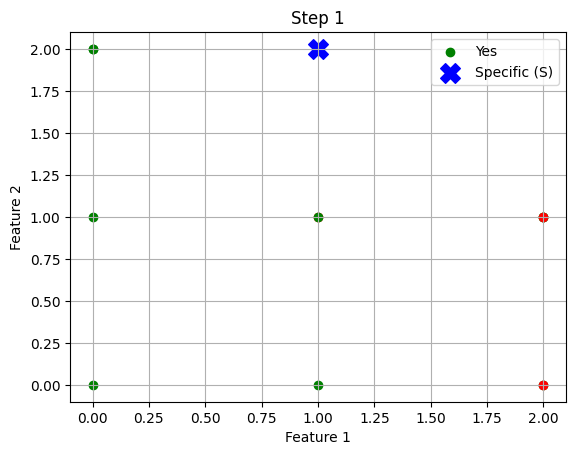

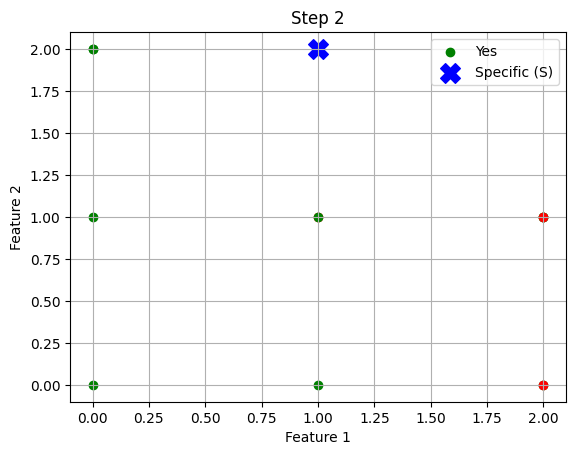

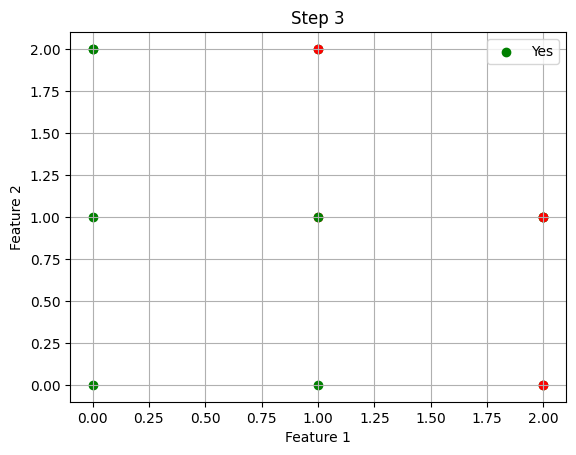

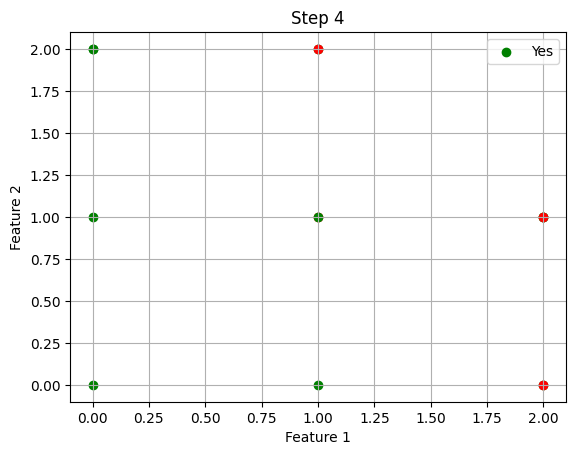

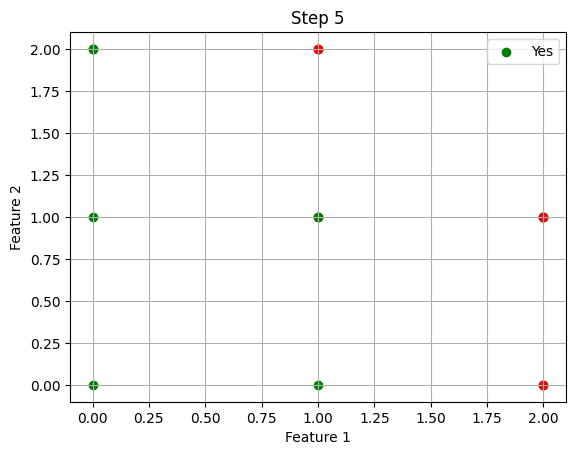

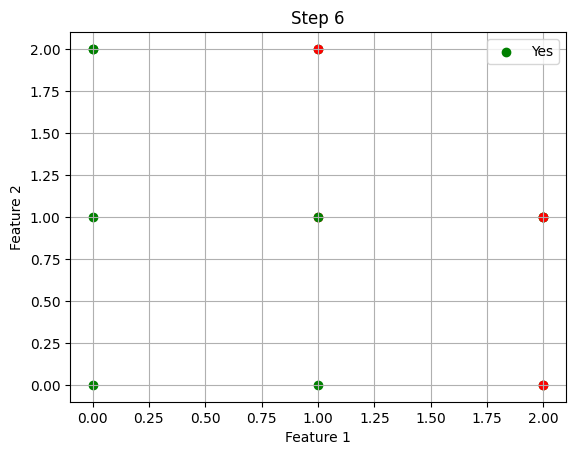

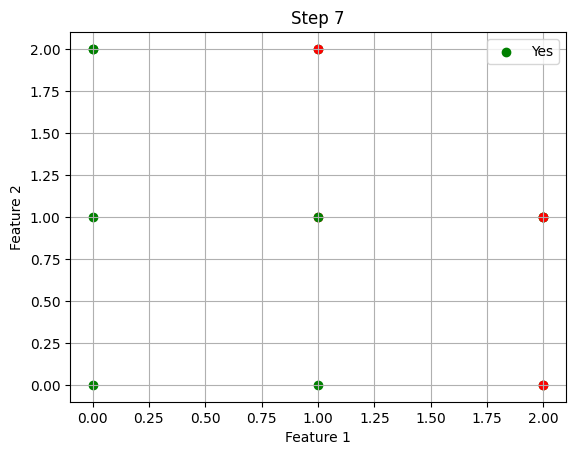

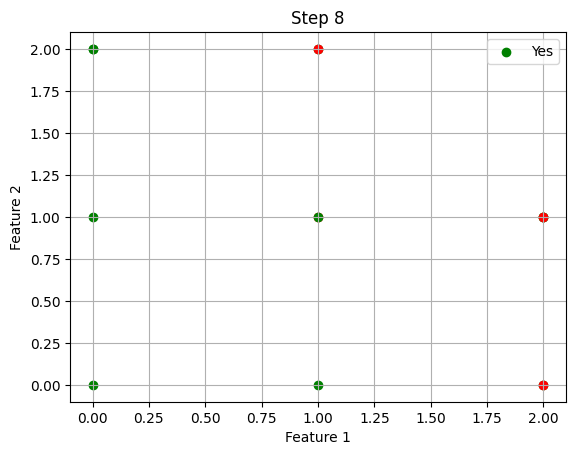

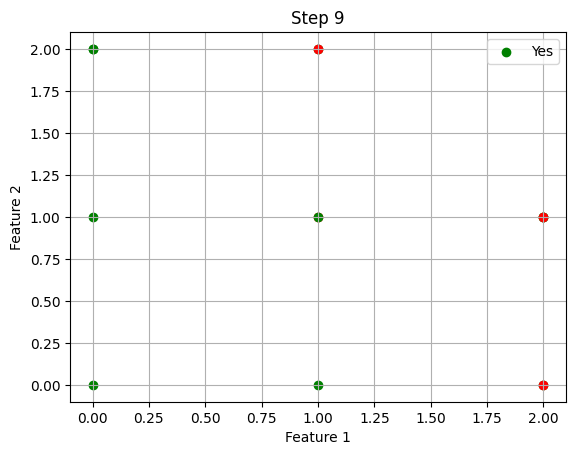

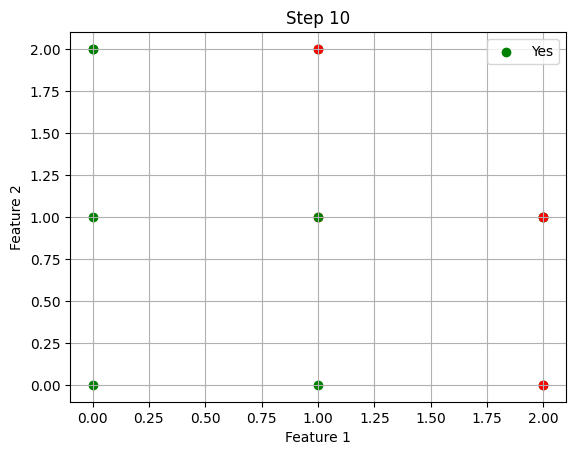

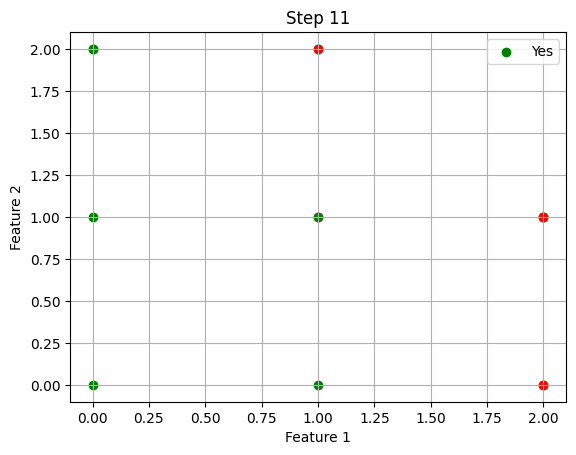

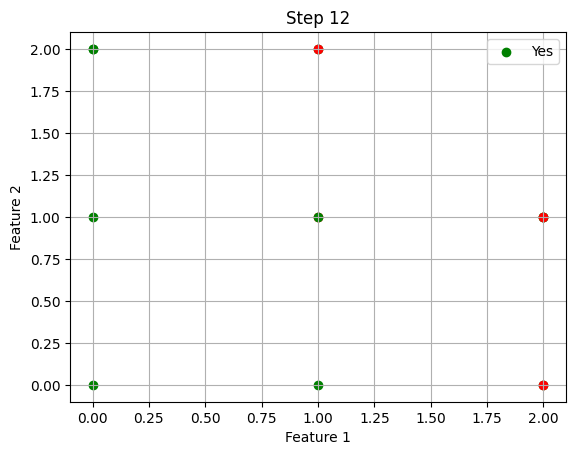

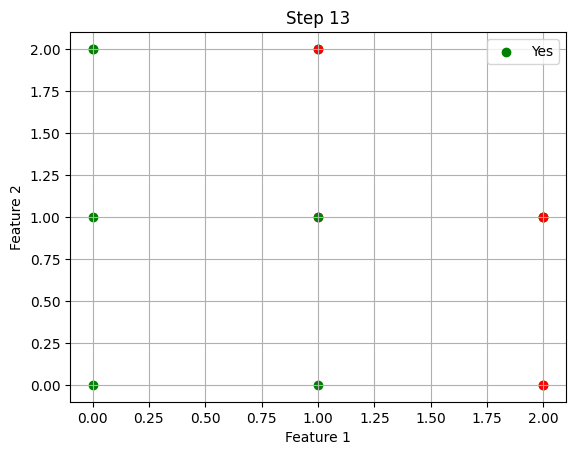

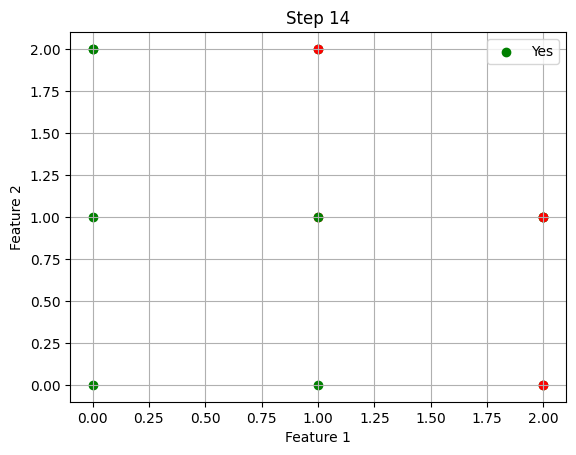

In [ ]:
from google.colab import files

uploaded = files.upload()

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = pd.read_csv("task2.csv")

concepts = np.array(data.iloc[:, :-1])
target = np.array(data.iloc[:, -1])

def candidate(concepts, target):

    specific = concepts[0].copy()
    general = [["?" for i in range(len(specific))] for i in range(len(specific))]

    print("Initial Specific:", specific)
    print("Initial General:", general)

    for i, instance in enumerate(concepts):

        print(f"\nInstance {i+1}: {instance} | Target: {target[i]}")

        if str(target[i]).lower() == "yes":
            print("YES DETECTED")
            for j in range(len(specific)):
                if instance[j] != specific[j]:
                    specific[j] = "?"
                    general[j][j] = "?"
            print("Updated Specific:", specific)

        elif str(target[i]).lower() == "no":
            print("NO DETECTED")
            for j in range(len(specific)):
                if instance[j] != specific[j]:
                    general[j][j] = specific[j]
                else:
                    general[j][j] = "?"
            print("Updated General:", general)

    general = [h for h in general if h != ["?" for _ in range(len(specific))]]
    return specific, general


specific, general = candidate(concepts, target)

print("\n=============================")
print("FINAL SPECIFIC HYPOTHESIS:")
print(specific)
print("FINAL GENERAL HYPOTHESIS:")
print(general)


conflicting_concept = concepts.copy()[0]

conflicting_target = "No"

print("Original Row 0 (YES):", concepts[0], "→ Yes")
print("Conflict Row   (NO) :", conflicting_concept, "→ No  ← SAME features, OPPOSITE label!")

concepts_conflict = np.vstack([concepts, conflicting_concept])
target_conflict = np.append(target, conflicting_target)

for i in range(len(concepts_conflict)):
    print(f"Row{i+1}: Features: {concepts_conflict[i]} target: {target_conflict[i]}")

print("\n--- Running Candidate Elimination on Conflicting Dataset ---")

specific_c, general_c = candidate(concepts_conflict, target_conflict)

print("\nFINAL SPECIFIC HYPOTHESIS (S) after conflict:")
print(specific_c)
print("FINAL GENERAL HYPOTHESIS (G) after conflict:")
print(general_c)

print("\n--- VERSION SPACE COLLAPSE CHECK ---")

all_question_marks = all(x == "?" for x in specific_c)
general_empty = len(general_c) == 0

if all_question_marks or general_empty:
    print("⚠️  VERSION SPACE COLLAPSED!")
    print("    The algorithm could NOT find any valid hypothesis.")
    print("    S became all '?' and G is empty — no rule satisfies both conflicting rows.")
else:
    print("✅ Version Space did NOT collapse.")
    print("   A valid hypothesis still exists.")

print("\n--- COMPARISON: Original vs Conflicting ---")
print(f"Original  S: {specific}")
print(f"Conflict  S: {specific_c}")
print(f"Original  G: {general}")
print(f"Conflict  G: {general_c}")


def plot_hypothesis_space(concepts, target):

    # Use only first 2 features for 2D plotting
    X = concepts[:, :2]

    # Convert categorical values to numeric
    unique_vals_0 = list(set(X[:, 0]))
    unique_vals_1 = list(set(X[:, 1]))

    mapping_0 = {val: i for i, val in enumerate(unique_vals_0)}
    mapping_1 = {val: i for i, val in enumerate(unique_vals_1)}

    X_num = np.array([[mapping_0[x[0]], mapping_1[x[1]]] for x in X])

    specific = concepts[0].copy()
    general = [["?" for _ in range(len(specific))] for _ in range(len(specific))]

    for step, instance in enumerate(concepts):

        # Plot data points
        plt.figure()

        for i in range(len(X_num)):
            if str(target[i]).lower() == "yes":
                plt.scatter(X_num[i][0], X_num[i][1], color='green', label='Yes' if i == 0 else "")
            else:
                plt.scatter(X_num[i][0], X_num[i][1], color='red', label='No' if i == 0 else "")

        # Update hypotheses (same logic as your function)
        if str(target[step]).lower() == "yes":
            for j in range(len(specific)):
                if instance[j] != specific[j]:
                    specific[j] = "?"
                    general[j][j] = "?"

        elif str(target[step]).lower() == "no":
            for j in range(len(specific)):
                if instance[j] != specific[j]:
                    general[j][j] = specific[j]
                else:
                    general[j][j] = "?"

        # Plot Specific boundary (S)
        if specific[0] != "?" and specific[1] != "?":
            x = mapping_0[specific[0]]
            y = mapping_1[specific[1]]
            plt.scatter(x, y, color='blue', marker='X', s=200, label='Specific (S)')

        # Plot General boundary (G)
        for g in general:
            if g[0] != "?" and g[1] == "?":
                x = mapping_0[g[0]]
                plt.axvline(x=x, linestyle='--', color='purple', label='General (G)')
            elif g[1] != "?" and g[0] == "?":
                y = mapping_1[g[1]]
                plt.axhline(y=y, linestyle='--', color='purple', label='General (G)')

        plt.title(f"Step {step+1}")
        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        plt.legend()
        plt.grid()
        plt.show()


plot_hypothesis_space(concepts, target)